<a href="https://colab.research.google.com/github/nikamade/Data201/blob/main/Assignment_week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **DATA 201 -- Week 3 Assignment**
## **Visualization + Linear Regression (R → Python Bridge)**
**Submission**: Jupyter Notebook (.ipynb) in Github + attach to Team
**Dataset**: housing.csv
**Focus**: Interpretation > Syntax

## **Part I -- Visualization (40 pts)**
### **A. Scatterplots and Aesthetics**
Create a scatterplot of **size vs price**.

Label axes clearly.
Add a meaningful title.
Recreate the plot using color = neighborhood (use seaborn).

Use transparency (alpha) to reduce overplotting.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/Reben80/Data201/refs/heads/main/Dataset/housing.csv")

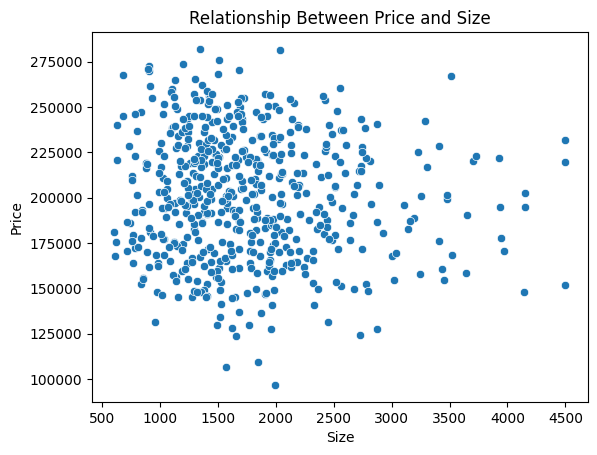

In [4]:
sns.scatterplot(data=df, x="size", y = "price")
plt.title("Relationship Between Price and Size")
plt.xlabel("Size")
plt.ylabel("Price")
plt.show()

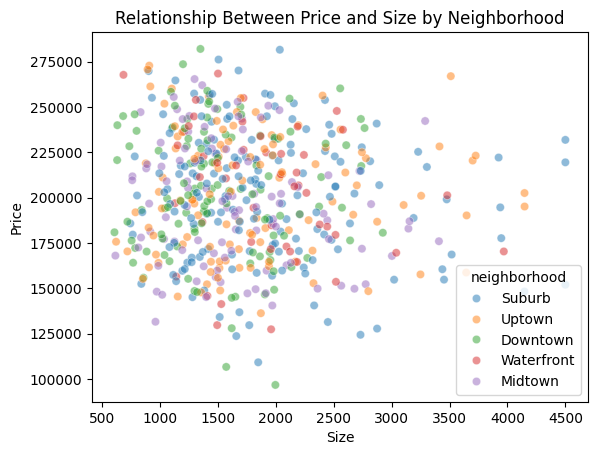

In [5]:
sns.scatterplot(data=df, x="size", y ="price",hue="neighborhood", alpha=0.5)
plt.title("Relationship Between Price and Size by Neighborhood")
plt.xlabel("Size")
plt.ylabel("Price")
plt.show()

### **Short Answer (3--4 sentences)**
What does seaborn automatically handle that matplotlib does not?//  ANSWER: works on dataframes, Separate the data by neighborhood
and assign colors to each neighborhood it also create the legend automatically.
Why is transparency useful here?// ANSWER: because it reduce overplotting when the point a together it is hard to study it withour transparency.

## **B. Small Multiples (Faceting)**
Create small multiples of **size vs price**, separated by bedrooms.

Keep scales consistent.
Add a clear overall title.

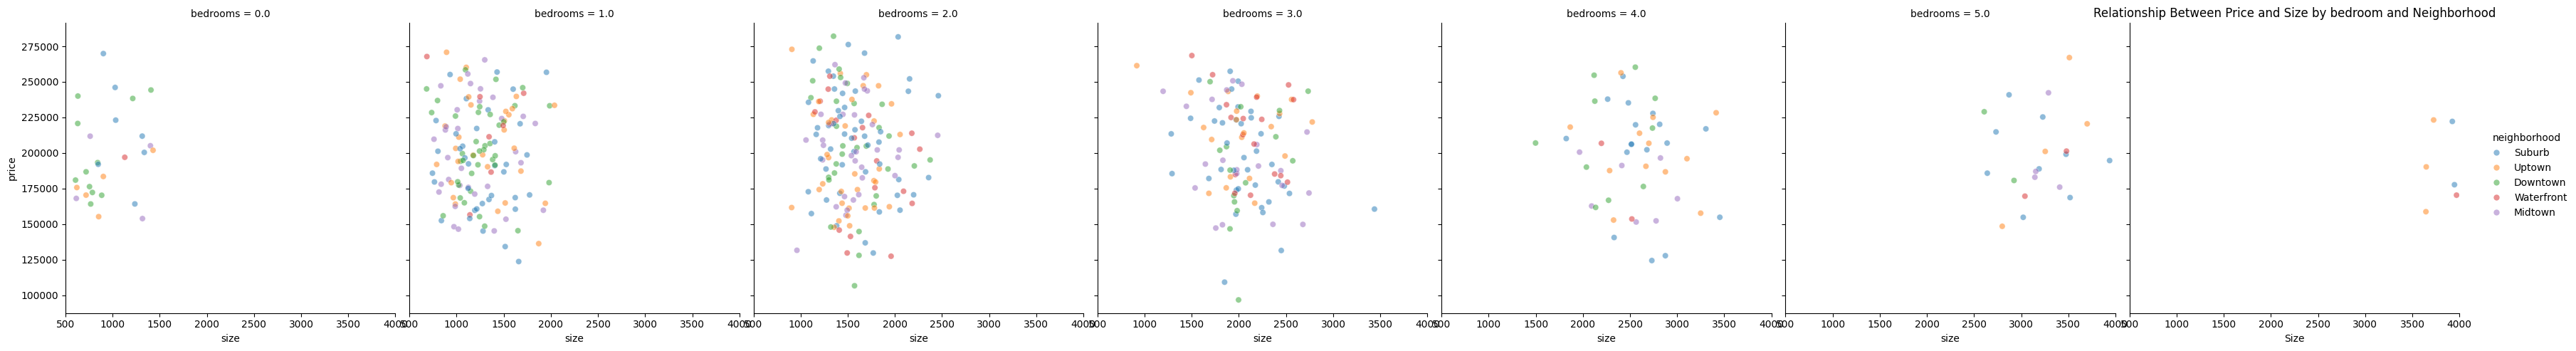

In [6]:
sns.relplot(data=df, x="size", y="price", col="bedrooms", hue= "neighborhood", alpha= 0.5 , kind="scatter")
plt.title("Relationship Between Price and Size by bedroom and Neighborhood")
plt.xlabel("Size")
plt.ylabel("Price")
plt.xlim(500, 4000)
plt.show()

### **Question**
Does the relationship between size and price look similar across bedroom counts? //  ANSWER: NO



## **C. Distribution and Categorical Plots*
Create a histogram of price.

Create a density plot of price.

Create a boxplot of price by neighborhood.



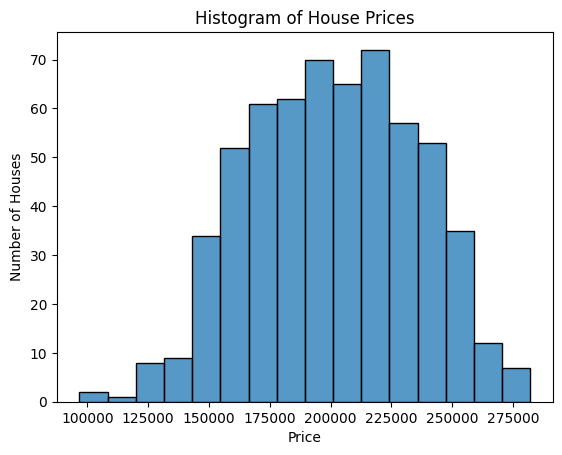

In [7]:
sns.histplot(data=df, x="price")
plt.title("Histogram of House Prices")
plt.xlabel("Price")
plt.ylabel("Number of Houses")
plt.show()

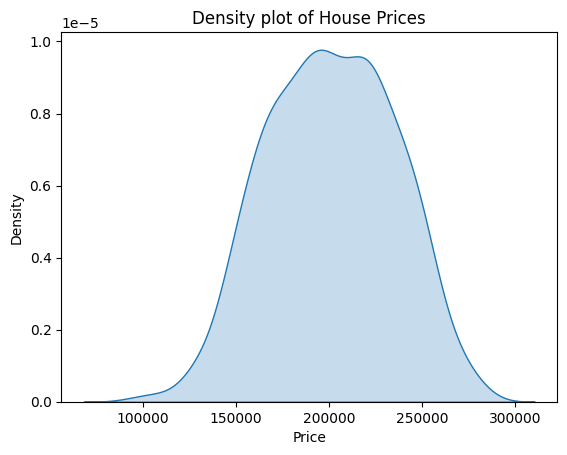

In [8]:
sns.kdeplot(data=df, x="price", fill=True)
plt.title("Density plot of House Prices")
plt.xlabel("Price")
plt.ylabel("Density")
plt.show()

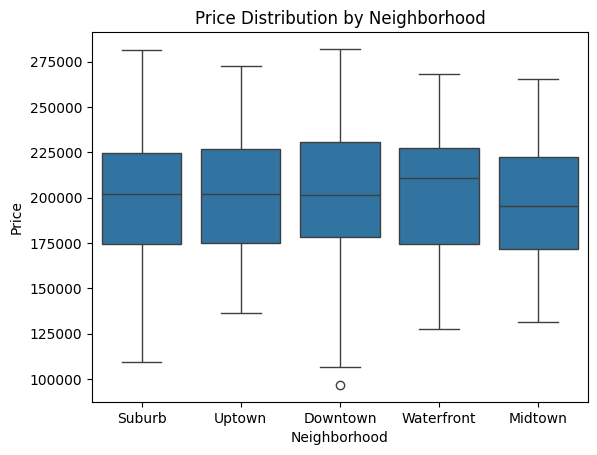

In [9]:
sns.boxplot(data=df, x="neighborhood", y="price")
plt.title("Price Distribution by Neighborhood")
plt.xlabel("Neighborhood")
plt.ylabel("Price")
plt.show()


### **Interpretation (short paragraph)**
Do neighborhoods differ systematically in price?
What visual evidence supports your claim?

yes neighborhood differ systematically in price the visual evidence who supports that is the boxplot beacuse we can see that the median varie and some neighborhood have higher price than others. here downtown neighborhood is the one theat price are higher.

# **Part II -- Linear Regression for Inference (30 pts)**

## **A. Multiple Regression (R → Python)**
In R, the model would be:

lm(price ~ size + bedrooms + neighborhood, data = df)
In Python:

Fit the equivalent model using statsmodels.
Report:

Coefficient estimates

Standard errors

R²

In [10]:
import statsmodels.formula.api as smf


In [11]:
model = smf.ols("price ~ size + bedrooms + C(neighborhood)", data=df).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     1.460
Date:                Thu, 12 Mar 2026   Prob (F-statistic):              0.190
Time:                        00:48:48   Log-Likelihood:                -6212.8
No. Observations:                 524   AIC:                         1.244e+04
Df Residuals:                     517   BIC:                         1.247e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
=================================================================================================
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                      2.112e+05   4925.106     42.872      0.000    2.01e+05    2.21e+05
C(neighborhood)[T.Midtown]    -4236.1877   4809.529     -0.881      0.379   -1.37e+04    5212.435
C(neighborhood)[T.Suburb]      -562.7029   4369.989     -0.129      0.898   -9147.823    8022.417
C(neighborhood)[T.Uptown]      1311.1025   4727.959      0.277      0.782   -7977.272    1.06e+04
C(neighborhood)[T.Waterfront]  3001.3355   5984.299      0.502      0.616   -8755.198    1.48e+04
size                            -10.9345      4.210     -2.597      0.010     -19.205      -2.664
bedrooms                       4372.2643   2262.445      1.933      0.054     -72.453    8816.981
==============================================================================
Omnibus:                       12.814   Durbin-Watson:                   0.699
Prob(Omnibus):                  0.002   Jarque-Bera (JB):                7.598
Skew:                          -0.114   Prob(JB):                       0.0224
Kurtosis:                       2.456   Cond. No.                     1.05e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.05e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Report:
Coefficient estimates

Intercept	2.112e+05 dc 211200

C(neighborhood)[T.Midtown]	-4236.1877

C(neighborhood)[T.Suburb]

C(neighborhood)[T.Uptown

C(neighborhood)[T.Waterfront]	3001.3355

size	-10.9345

bedrooms	4372.2643


Standard errors


Intercept		4925.106

C(neighborhood)[T.Midtown] 4809.529

C(neighborhood)[T.Suburb]	4369.989

C(neighborhood)[T.Uptown]	4727.959

C(neighborhood)[T.Waterfront]	5984.299

size	4.210

bedrooms	2262.445

R² : 	0.017

**B. Interpretation**
Answer clearly:

Interpret the coefficient on size, explicitly stating what is being held constant.

**ANSWER**: for each additional square foot of house size, the predicted price decreases by approximately $10.93


Is size statistically significant? How do you know?
ANSWER: yes because the p.value
which is 0.010 and its is < 0.05


What does R² tell us in this
context? 0.017 means that only about 1.7% of the variation in house prices is explained by ibdependant variable size ...

## **Part III -- Prediction Workflow (20 pts)**
Now switch goals: Prediction instead of explanation

Split the data into training and test sets.
Fit linear regression using scikit-learn.
Compute:
RMSE (on test set)
R² (on test set)


In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
df = df.dropna()
X = df[["size", "bedrooms"]]
y = df["price"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("rmse:", rmse)
print("r2:", r2)

rmse: 37148.4305482652
r2: -0.05638645713273993


### **Short Answer**
Why does scikit-learn not report p-values?

ANSWER: because it focus only on prediction not statiscal inference in order to have good prediction  
Which workflow would you use for:
Explanation?

ANSWER:  For explanatiuon I should use statmodels because its provide statistical information
Prediction?

ANSWER : for prediction i should use scikit-learn
Why are these different goals?

ANSWER: Explanation focuses on understanding relationships between variables, while prediction focuses on making accurate predictions.

### **Part IV -- Integrated Thinking (10 pts)**
Create one polished figure that:

Shows size vs price
Colors by neighborhood
Includes a regression line
Has professional formatting



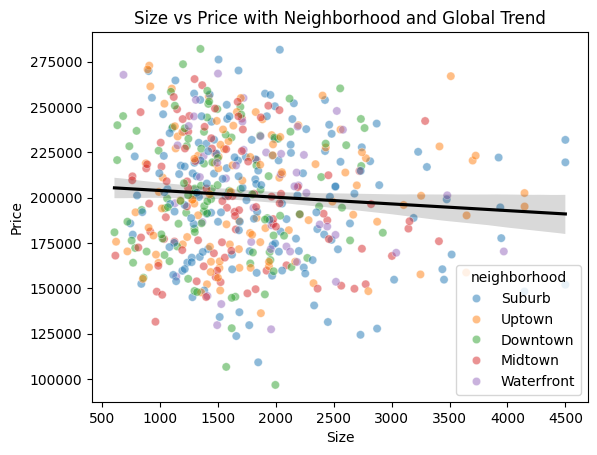

In [18]:

sns.scatterplot(data=df, x="size", y="price", hue="neighborhood", alpha=0.5)

sns.regplot(data=df, x="size", y="price", scatter=False, color="black")

plt.title("Size vs Price with Neighborhood and Global Trend")
plt.xlabel("Size")
plt.ylabel("Price")
plt.show()

 ### **Small Essay**
Yes, the regression model shows a negative slope, which does not entirely match what I see in the scatterplot. From the scatterplot, it is clear that larger houses generally have higher prices, but the model predicts that larger houses have lower prices. This happens because some large houses in the dataset have relatively low prices.Yes,the visualization help you anticipate the model results because I can see that some small houses have high prices. This suggests that other variables besides size, such as neighborhood or number of bedrooms, need to be considered in the model to better explain house prices.